# Alternative Architectures for CAMELS Profile Emulation

This notebook explores two architectures that drop the Neural Process context-set
abstraction while retaining the key modelling capabilities (FiLM conditioning on θ,
CC/NCC dual heads, stochastic latent variables).

## Approach 1 — Conditional ResNet
A deep 1-D ResNet that takes `(log M, log r, θ)` on a **fixed radial grid** and
outputs all thermodynamic channels `(T, P, ρ)` jointly.  θ conditioning is applied
via FiLM layers.  Dual CC / NCC output heads are kept without ANP machinery.

## Approach 2 — Conditional VAE (CVAE)
A latent-variable model that keeps a global latent `z` per halo (or per run) to
capture CC-vs-NCC stochasticity, but samples `z` from a simple encoder
`q(z | θ, M)` instead of an NP context encoder.  The decoder maps
`(M, r, θ, z) → (T, P, ρ)` with dual CC / NCC heads.

---

## 0. Setup & Data Loading

In [1]:
from __future__ import annotations

import math
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, kl_divergence
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# ── Load CAMELS profiles and build a flat (M, r, θ) → y dataset ──────────────
# We use the 1P profile files shipped with the repo for quick iteration.
# For a production run, point PROFILE_DIR at the full SB35 set and supply
# the matching param_df.csv.

PROFILE_DIR = Path('Profiles_cy')          # local 1P subset
MASS_CUT    = 1e12                          # minimum M500c [M_sun]
CHANNELS    = ['gas_density', 'temperature', 'pressure']  # output channels
LOG_CHANNELS = {'gas_density', 'temperature', 'pressure'}
N_R_FIXED   = 30                            # fixed radial grid size
THETA_DIM   = 35                            # CAMELS feedback params

# ── Discover & load profile files ──
npz_files = sorted(PROFILE_DIR.glob('*.npz'))
print(f'Found {len(npz_files)} profile files')


def load_profiles(npz_path: Path, mass_cut: float = MASS_CUT):
    """Load a single NPZ and return per-halo data above mass_cut."""
    d = np.load(npz_path, allow_pickle=True)
    m500 = d['M500c'].astype(np.float32)
    r500 = d['R500c'].astype(np.float32)
    radial_bins = d['radial_bins'].astype(np.float32)  # (n_r,) physical kpc
    mask = m500 >= mass_cut
    if mask.sum() == 0:
        return None
    m500 = m500[mask]
    r500 = r500[mask]
    # Profiles: (n_halo, n_r)
    profiles = {}
    for ch in CHANNELS:
        arr = d[f'{ch}_array'].astype(np.float32)[mask]
        if ch in LOG_CHANNELS:
            arr = np.log10(np.clip(arr, 1e-30, None))
        profiles[ch] = arr
    # r / R500 ratios
    rr500 = radial_bins[None, :] / r500[:, None]  # (n_halo, n_r)
    log_rr500 = np.log10(rr500).astype(np.float32)
    log_m500 = np.log10(m500).astype(np.float32)
    # CC indicator: log10(T_core / T500_analytic)
    T_keV = d['temperature_array'].astype(np.float64)[mask]
    T_core = T_keV[:, :6].mean(axis=1)
    G, kb, mp, mu = 6.674e-8, 1.381e-16, 1.673e-24, 0.59
    Msun, kpc, keV2K = 1.989e33, 3.086e21, 1.16e7
    T500_K = mu * mp * G * (m500.astype(np.float64) * Msun) / (2 * kb * (r500.astype(np.float64) * kpc))
    T500_keV = T500_K / keV2K
    cc_indicator = np.log10(np.clip(T_core, 1e-30, None) / np.clip(T500_keV, 1e-30, None)).astype(np.float32)
    return {
        'log_m500': log_m500,     # (n_halo,)
        'log_rr500': log_rr500,   # (n_halo, n_r)
        'profiles': profiles,     # dict of (n_halo, n_r)
        'cc_indicator': cc_indicator,  # (n_halo,)
    }


all_data = []
for fp in npz_files:
    result = load_profiles(fp)
    if result is not None:
        all_data.append(result)

print(f'Loaded {len(all_data)} files with valid halos')
print(f'Total halos: {sum(d["log_m500"].shape[0] for d in all_data)}')

Found 188 profile files
Loaded 188 files with valid halos
Total halos: 23278


In [3]:
# ── Flatten into tensors for direct (M, r, θ) → y training ──────────────────
# For this exploration we use a dummy θ (fiducial CAMELS) since the 1P files
# share the same base parameters.  For real training, load param_df.csv.

theta_fid = np.zeros(THETA_DIM, dtype=np.float32)  # placeholder

X_parts = []   # (N, 2 + THETA_DIM):  [logM, logr, θ_1..θ_35]
Y_parts = []   # (N, n_channels)
CC_parts = []  # (N,)  CC indicator per point (constant over r for a halo)

for d in all_data:
    n_h, n_r = d['log_rr500'].shape
    logM = np.broadcast_to(d['log_m500'][:, None], (n_h, n_r)).reshape(-1)  # (N,)
    logr = d['log_rr500'].reshape(-1)  # (N,)
    theta_tile = np.broadcast_to(theta_fid[None, None, :], (n_h, n_r, THETA_DIM)).reshape(-1, THETA_DIM)
    x = np.column_stack([logM, logr, theta_tile])  # (N, 37)
    y = np.column_stack([d['profiles'][ch].reshape(-1) for ch in CHANNELS])  # (N, 3)
    cc = np.broadcast_to(d['cc_indicator'][:, None], (n_h, n_r)).reshape(-1)
    X_parts.append(x)
    Y_parts.append(y)
    CC_parts.append(cc)

X_np = np.concatenate(X_parts, axis=0).astype(np.float32)
Y_np = np.concatenate(Y_parts, axis=0).astype(np.float32)
CC_np = np.concatenate(CC_parts, axis=0).astype(np.float32)

print(f'X shape: {X_np.shape}   Y shape: {Y_np.shape}   CC shape: {CC_np.shape}')
print(f'logM range:  [{X_np[:, 0].min():.2f}, {X_np[:, 0].max():.2f}]')
print(f'logr range:  [{X_np[:, 1].min():.2f}, {X_np[:, 1].max():.2f}]')
print(f'CC range:    [{CC_np.min():.3f}, {CC_np.max():.3f}]')
for i, ch in enumerate(CHANNELS):
    print(f'  {ch:20s}  [{Y_np[:, i].min():.3f}, {Y_np[:, i].max():.3f}]')

X shape: (698340, 37)   Y shape: (698340, 3)   CC shape: (698340,)
logM range:  [12.02, 14.68]
logr range:  [-1.93, 1.57]
CC range:    [-2.386, 1.013]
  gas_density           [-30.000, -24.276]
  temperature           [-30.000, 1.103]
  pressure              [-30.000, -19.864]


In [4]:
# ── Normalize (train-split only) ────────────────────────────────────────────
n_total = X_np.shape[0]
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

rng = np.random.RandomState(42)
perm = rng.permutation(n_total)
idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train + n_val]
idx_test  = perm[n_train + n_val:]

# Compute stats on train split only
x_mean = X_np[idx_train].mean(axis=0)
x_std  = np.maximum(X_np[idx_train].std(axis=0), 1e-6)
y_mean = Y_np[idx_train].mean(axis=0)
y_std  = np.maximum(Y_np[idx_train].std(axis=0), 1e-6)

def normalize(arr, mu, sigma):
    return (arr - mu) / sigma

def denormalize(arr, mu, sigma):
    return arr * sigma + mu

X_norm = normalize(X_np, x_mean, x_std).astype(np.float32)
Y_norm = normalize(Y_np, y_mean, y_std).astype(np.float32)

# Build torch datasets
def make_dataset(idx):
    return TensorDataset(
        torch.from_numpy(X_norm[idx]),
        torch.from_numpy(Y_norm[idx]),
        torch.from_numpy(CC_np[idx]),
    )

ds_train = make_dataset(idx_train)
ds_val   = make_dataset(idx_val)
ds_test  = make_dataset(idx_test)

BATCH_SIZE = 4096
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(ds_train):,}   Val: {len(ds_val):,}   Test: {len(ds_test):,}')

Train: 558,672   Val: 69,834   Test: 69,834


---
## 1. Approach 1 — Conditional ResNet with FiLM + Dual CC/NCC Heads

### Architecture

```
Input: [logM_norm, logr_norm, θ_1..θ_35]  (37 dims, normalized)
              │
     ┌────────▼────────┐
     │  Input MLP      │  37 → hidden
     └────────┬────────┘
              │
     ┌────────▼────────┐
     │  ResBlock + FiLM│ ← θ conditions via FiLM (γ, β)
     │  ResBlock + FiLM│
     │   ... × N       │
     └────┬────────┬───┘
          │        │
   ┌──────▼──┐ ┌───▼──────┐
   │ NCC head│ │ CC head  │  each → (μ, σ) × 3 channels
   └─────────┘ └──────────┘
```

- **No context set / no NP encoder**: just direct `(θ, M, r) → (T, P, ρ)` samples.
- θ-conditioning via **FiLM** (Feature-wise Linear Modulation) inside each ResBlock.
- **Dual output heads** for CC vs NCC halos — routed by the CC indicator at training
  and blended at inference time.
- Heteroscedastic Gaussian outputs: predicts `(μ, σ)` per channel.

In [5]:
# ── Conditional ResNet with FiLM ─────────────────────────────────────────────

class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation: h ← h * (1 + s*tanh(γ)) + s*β."""

    def __init__(self, cond_dim: int, hidden_dim: int, scale: float = 0.1):
        super().__init__()
        self.film = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim * 2),
            nn.SiLU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
        )
        self.scale = scale

    def forward(self, h: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        gb = self.film(cond)
        gamma, beta = gb.chunk(2, dim=-1)
        return h * (1.0 + self.scale * torch.tanh(gamma)) + self.scale * beta


class FiLMResBlock(nn.Module):
    """Pre-activation ResNet block with FiLM conditioning."""

    def __init__(self, hidden_dim: int, cond_dim: int, dropout: float = 0.1,
                 film_scale: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.fc1   = nn.Linear(hidden_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.fc2   = nn.Linear(hidden_dim, hidden_dim)
        self.drop  = nn.Dropout(dropout)
        self.film  = FiLMLayer(cond_dim, hidden_dim, scale=film_scale)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        h = F.silu(self.fc1(h))
        h = self.drop(h)
        h = self.film(h, cond)
        h = self.norm2(h)
        h = F.silu(self.fc2(h))
        h = self.drop(h)
        return x + h


class GaussianHead(nn.Module):
    """Predict (μ, σ) for y_dim channels."""

    def __init__(self, hidden_dim: int, y_dim: int):
        super().__init__()
        self.mu = nn.Linear(hidden_dim, y_dim)
        self.log_sigma = nn.Linear(hidden_dim, y_dim)

    def forward(self, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mu = self.mu(h)
        sigma = 0.1 + 0.9 * F.softplus(self.log_sigma(h))
        return mu, sigma


class ConditionalResNet(nn.Module):
    """Deep ResNet: (logM, logr, θ) → (T, P, ρ) with FiLM + dual heads.

    Parameters
    ----------
    x_dim : int
        Full input dimension (2 + theta_dim).
    y_dim : int
        Number of output channels.
    hidden_dim : int
        Width of residual blocks.
    n_blocks : int
        Number of FiLM-conditioned residual blocks.
    theta_start : int
        Index where θ features begin in x.
    theta_dim : int
        Dimensionality of θ conditioning vector.
    film_scale : float
        FiLM modulation strength.
    dropout : float
        Dropout rate in residual blocks.
    """

    def __init__(
        self,
        x_dim: int = 37,
        y_dim: int = 3,
        hidden_dim: int = 256,
        n_blocks: int = 6,
        theta_start: int = 2,
        theta_dim: int = 35,
        film_scale: float = 0.1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.theta_start = theta_start
        self.theta_dim = theta_dim

        self.input_proj = nn.Sequential(
            nn.Linear(x_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.blocks = nn.ModuleList([
            FiLMResBlock(hidden_dim, theta_dim, dropout=dropout, film_scale=film_scale)
            for _ in range(n_blocks)
        ])
        self.final_norm = nn.LayerNorm(hidden_dim)

        # Dual output heads
        self.head_ncc = GaussianHead(hidden_dim, y_dim)
        self.head_cc  = GaussianHead(hidden_dim, y_dim)

    def _trunk(self, x: torch.Tensor) -> torch.Tensor:
        theta = x[:, self.theta_start : self.theta_start + self.theta_dim]
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h, theta)
        return self.final_norm(h)

    def forward(self, x: torch.Tensor):
        """Return (mu_ncc, sig_ncc), (mu_cc, sig_cc)."""
        h = self._trunk(x)
        return self.head_ncc(h), self.head_cc(h)

    def predict(self, x: torch.Tensor, p_cc: Optional[torch.Tensor] = None):
        """Blended prediction: p_cc * cc_head + (1 - p_cc) * ncc_head."""
        (mu_ncc, sig_ncc), (mu_cc, sig_cc) = self.forward(x)
        if p_cc is None:
            p_cc = torch.full((x.shape[0], 1), 0.5, device=x.device)
        elif p_cc.dim() == 1:
            p_cc = p_cc.unsqueeze(-1)
        mu  = p_cc * mu_cc  + (1 - p_cc) * mu_ncc
        var = p_cc * (sig_cc**2 + mu_cc**2) + (1 - p_cc) * (sig_ncc**2 + mu_ncc**2) - mu**2
        sig = torch.sqrt(var.clamp(min=1e-8))
        return mu, sig


# Quick size check
model_resnet = ConditionalResNet(
    x_dim=2 + THETA_DIM, y_dim=len(CHANNELS),
    hidden_dim=256, n_blocks=6,
    theta_start=2, theta_dim=THETA_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in model_resnet.parameters())
print(f'ConditionalResNet parameters: {n_params:,}')

# Smoke test
with torch.no_grad():
    x_test = torch.randn(8, 2 + THETA_DIM, device=DEVICE)
    (mu_ncc, sig_ncc), (mu_cc, sig_cc) = model_resnet(x_test)
    print(f'mu_ncc shape: {mu_ncc.shape}  sig_ncc shape: {sig_ncc.shape}')

ConditionalResNet parameters: 2,561,292
mu_ncc shape: torch.Size([8, 3])  sig_ncc shape: torch.Size([8, 3])


### 1.1 Training the Conditional ResNet

In [6]:
def train_resnet(
    model: ConditionalResNet,
    dl_train: DataLoader,
    dl_val: DataLoader,
    epochs: int = 60,
    lr: float = 3e-4,
    cc_threshold: float = 0.0,
    device: torch.device = DEVICE,
) -> Dict[str, list]:
    """Train with Gaussian NLL, routing to CC/NCC heads by cc_indicator."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        epoch_loss = 0.0
        n_pts = 0
        for xb, yb, ccb in dl_train:
            xb, yb, ccb = xb.to(device), yb.to(device), ccb.to(device)
            (mu_ncc, sig_ncc), (mu_cc, sig_cc) = model(xb)

            # Route: CC if cc_indicator < threshold
            is_cc = (ccb < cc_threshold).unsqueeze(-1)  # (B, 1)
            mu  = torch.where(is_cc, mu_cc,  mu_ncc)
            sig = torch.where(is_cc, sig_cc, sig_ncc)

            # Gaussian NLL
            nll = 0.5 * (((yb - mu) / sig) ** 2 + 2 * sig.log() + math.log(2 * math.pi))
            loss = nll.mean()

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            epoch_loss += loss.item() * xb.shape[0]
            n_pts += xb.shape[0]

        scheduler.step()
        history['train_loss'].append(epoch_loss / n_pts)

        # ── Validate ──
        model.eval()
        val_loss = 0.0
        vn = 0
        with torch.no_grad():
            for xb, yb, ccb in dl_val:
                xb, yb, ccb = xb.to(device), yb.to(device), ccb.to(device)
                (mu_ncc, sig_ncc), (mu_cc, sig_cc) = model(xb)
                is_cc = (ccb < cc_threshold).unsqueeze(-1)
                mu  = torch.where(is_cc, mu_cc,  mu_ncc)
                sig = torch.where(is_cc, sig_cc, sig_ncc)
                nll = 0.5 * (((yb - mu) / sig) ** 2 + 2 * sig.log() + math.log(2 * math.pi))
                val_loss += nll.mean().item() * xb.shape[0]
                vn += xb.shape[0]
        history['val_loss'].append(val_loss / vn)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train={history["train_loss"][-1]:.4f}  '
                  f'val={history["val_loss"][-1]:.4f}')

    return history


print('Training ConditionalResNet...')
hist_resnet = train_resnet(model_resnet, dl_train, dl_val, epochs=60)

Training ConditionalResNet...
  Epoch   1/60  train=0.1053  val=-0.1944
  Epoch  10/60  train=-0.2210  val=-0.2429
  Epoch  20/60  train=-0.2325  val=-0.2753
  Epoch  30/60  train=-0.2532  val=-0.2814
  Epoch  40/60  train=-0.2389  val=-0.2649
  Epoch  50/60  train=-0.2575  val=-0.2857
  Epoch  60/60  train=-0.2527  val=-0.2852


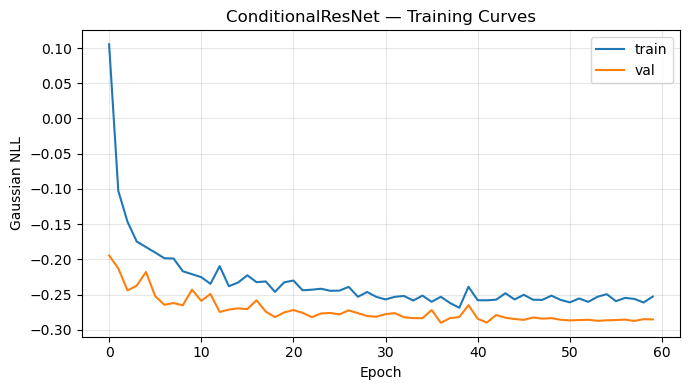

In [7]:
# ── Loss curves ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_resnet['train_loss'], label='train')
ax.plot(hist_resnet['val_loss'],   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gaussian NLL')
ax.set_title('ConditionalResNet — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Evaluate the Conditional ResNet on the test set

In [8]:
def evaluate_model(model, dl_test, y_mean_t, y_std_t, channels, device=DEVICE,
                   cc_threshold=0.0, is_cvae=False):
    """Compute per-channel RMSE in original (log10) space on test set."""
    model.eval()
    all_mu, all_y = [], []
    with torch.no_grad():
        for batch in dl_test:
            xb, yb = batch[0].to(device), batch[1].to(device)
            ccb = batch[2].to(device)
            if is_cvae:
                mu, _ = model.predict(xb)
            else:
                is_cc = (ccb < cc_threshold).float().unsqueeze(-1)
                mu, _ = model.predict(xb, p_cc=is_cc)
            all_mu.append(mu.cpu())
            all_y.append(yb.cpu())

    all_mu = torch.cat(all_mu, dim=0)
    all_y  = torch.cat(all_y, dim=0)

    # Denormalize
    mu_phys = all_mu * y_std_t + y_mean_t
    y_phys  = all_y  * y_std_t + y_mean_t

    rmse = {}
    for i, ch in enumerate(channels):
        rmse[ch] = float(((mu_phys[:, i] - y_phys[:, i]) ** 2).mean().sqrt())
    return rmse, mu_phys.numpy(), y_phys.numpy()


y_mean_t = torch.from_numpy(y_mean)
y_std_t  = torch.from_numpy(y_std)

rmse_resnet, pred_resnet, true_resnet = evaluate_model(
    model_resnet, dl_test, y_mean_t, y_std_t, CHANNELS)

print('ConditionalResNet test RMSE (log10 space):')
for ch, val in rmse_resnet.items():
    print(f'  {ch:20s}  {val:.4f} dex')

ConditionalResNet test RMSE (log10 space):
  gas_density           0.2561 dex
  temperature           0.9917 dex
  pressure              0.3987 dex


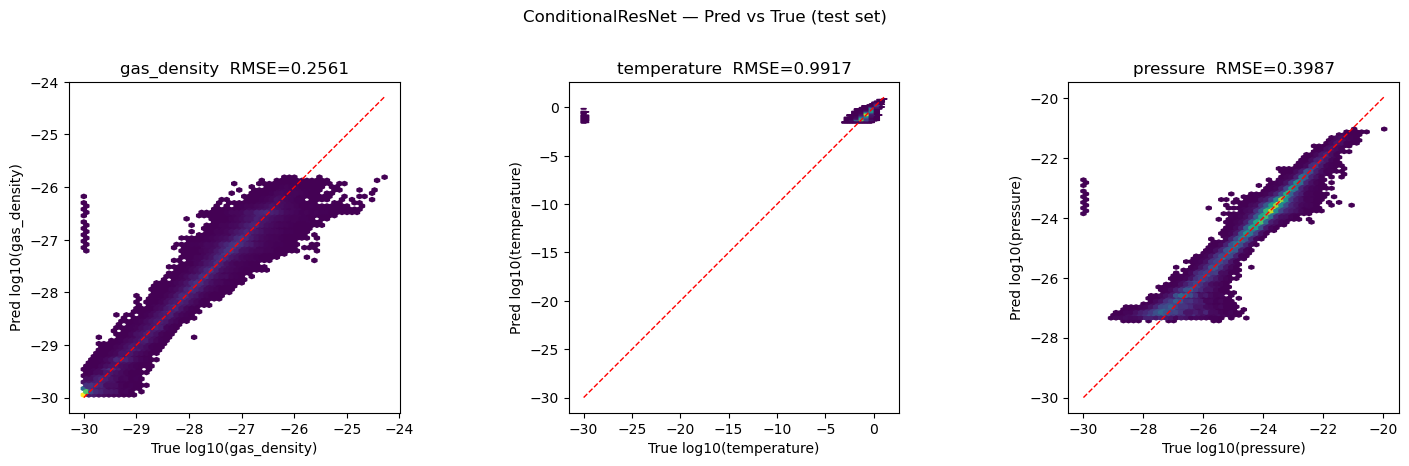

In [9]:
# ── Pred vs True scatter for ResNet ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(5 * len(CHANNELS), 4.5))
for i, (ch, ax) in enumerate(zip(CHANNELS, axes)):
    ax.hexbin(true_resnet[:, i], pred_resnet[:, i],
              gridsize=60, cmap='viridis', mincnt=1)
    lims = [min(true_resnet[:, i].min(), pred_resnet[:, i].min()),
            max(true_resnet[:, i].max(), pred_resnet[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'True log10({ch})')
    ax.set_ylabel(f'Pred log10({ch})')
    ax.set_title(f'{ch}  RMSE={rmse_resnet[ch]:.4f}')
    ax.set_aspect('equal')
fig.suptitle('ConditionalResNet — Pred vs True (test set)', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Approach 2 — Conditional VAE (CVAE)

### Architecture

```
                         ┌─────────────────┐
 (logM, θ) ──────────►  │  Encoder q(z|M,θ)│ → μ_z, σ_z → z ~ N(μ,σ)
                         └─────────────────┘         │
                                                     │
 (logM, logr, θ) ──►  ┌─────────────────────┐       │
                       │  Decoder trunk      │◄──────┘
                       │  + FiLM(θ)          │
                       └──┬──────────────┬───┘
                          │              │
                   ┌──────▼──┐    ┌──────▼──┐
                   │ NCC head│    │ CC head │  each → (μ, σ) × 3 channels
                   └─────────┘    └─────────┘
```

- Encoder `q(z | θ, M)` is a small MLP that maps `(logM, θ)` → latent `z` distribution.
- Prior `p(z) = N(0, I)` — standard normal.
- Decoder `(logM, logr, θ, z) → (T, P, ρ)` — same FiLM-conditioned ResNet trunk
  as Approach 1, but with `z` concatenated to the input.
- ELBO training: `L = -E_q[log p(y|x,z)] + β·KL[q(z|M,θ) || p(z)]`
  with β warmup to prevent posterior collapse.
- Dual CC/NCC heads as before.

In [10]:
# ── Conditional VAE ──────────────────────────────────────────────────────────

class CVAEncoder(nn.Module):
    """Encoder q(z | logM, θ): maps halo-level features to latent distribution."""

    def __init__(self, in_dim: int, d_latent: int, hidden_dim: int = 128, n_layers: int = 3):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_dim
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden_dim), nn.SiLU()]
            prev = hidden_dim
        self.net = nn.Sequential(*layers)
        self.mu = nn.Linear(hidden_dim, d_latent)
        self.log_sigma = nn.Linear(hidden_dim, d_latent)

    def forward(self, x: torch.Tensor) -> Normal:
        h = self.net(x)
        mu = self.mu(h)
        sigma = 0.1 + 0.9 * F.softplus(self.log_sigma(h))
        return Normal(mu, sigma)


class ConditionalVAE(nn.Module):
    """CVAE: q(z|M,θ) encoder + ResNet decoder with FiLM + dual heads.

    Parameters
    ----------
    x_dim : int
        Full input dimension (2 + theta_dim).
    y_dim : int
        Number of output channels.
    d_latent : int
        Latent dimension for z.
    hidden_dim : int
        Width of decoder residual blocks.
    n_blocks : int
        Number of FiLM-conditioned residual blocks.
    theta_start : int
        Index where θ features begin in x.
    theta_dim : int
        Dimensionality of θ conditioning vector.
    """

    def __init__(
        self,
        x_dim: int = 37,
        y_dim: int = 3,
        d_latent: int = 16,
        hidden_dim: int = 256,
        n_blocks: int = 6,
        theta_start: int = 2,
        theta_dim: int = 35,
        film_scale: float = 0.1,
        dropout: float = 0.1,
        enc_hidden: int = 128,
        enc_layers: int = 3,
    ):
        super().__init__()
        self.theta_start = theta_start
        self.theta_dim = theta_dim
        self.d_latent = d_latent

        # Encoder: q(z | logM, θ)  — only halo-level features, no radial info
        enc_in_dim = 1 + theta_dim   #  logM + θ
        self.encoder = CVAEncoder(enc_in_dim, d_latent, hidden_dim=enc_hidden,
                                  n_layers=enc_layers)

        # Decoder trunk: (logM, logr, θ, z) → hidden
        dec_in_dim = x_dim + d_latent
        self.input_proj = nn.Sequential(
            nn.Linear(dec_in_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.blocks = nn.ModuleList([
            FiLMResBlock(hidden_dim, theta_dim, dropout=dropout, film_scale=film_scale)
            for _ in range(n_blocks)
        ])
        self.final_norm = nn.LayerNorm(hidden_dim)

        # Dual output heads
        self.head_ncc = GaussianHead(hidden_dim, y_dim)
        self.head_cc  = GaussianHead(hidden_dim, y_dim)

    def _encode(self, x: torch.Tensor) -> Normal:
        """Encode halo-level features → latent posterior."""
        logM  = x[:, 0:1]
        theta = x[:, self.theta_start : self.theta_start + self.theta_dim]
        return self.encoder(torch.cat([logM, theta], dim=-1))

    def _decode(self, x: torch.Tensor, z: torch.Tensor):
        """Decode (x, z) → dual head outputs."""
        theta = x[:, self.theta_start : self.theta_start + self.theta_dim]
        h = self.input_proj(torch.cat([x, z], dim=-1))
        for block in self.blocks:
            h = block(h, theta)
        h = self.final_norm(h)
        return self.head_ncc(h), self.head_cc(h)

    def forward(self, x: torch.Tensor):
        """Training forward: sample z from posterior, return outputs + KL."""
        q_z = self._encode(x)
        z = q_z.rsample()  # reparameterized sample
        ncc_out, cc_out = self._decode(x, z)
        # KL against standard normal prior
        p_z = Normal(torch.zeros_like(q_z.loc), torch.ones_like(q_z.scale))
        kl = kl_divergence(q_z, p_z).sum(dim=-1)  # (B,)
        return ncc_out, cc_out, kl

    def predict(self, x: torch.Tensor, n_samples: int = 30,
                p_cc: Optional[torch.Tensor] = None):
        """Inference: MC-sample z and aggregate predictions."""
        q_z = self._encode(x)
        mus = []
        for _ in range(n_samples):
            z = q_z.rsample()
            ncc_out, cc_out = self._decode(x, z)
            mu_ncc, sig_ncc = ncc_out
            mu_cc, sig_cc   = cc_out
            if p_cc is None:
                p = torch.full((x.shape[0], 1), 0.5, device=x.device)
            elif p_cc.dim() == 1:
                p = p_cc.unsqueeze(-1)
            else:
                p = p_cc
            mu = p * mu_cc + (1 - p) * mu_ncc
            mus.append(mu)
        mus = torch.stack(mus, dim=0)   # (S, B, y_dim)
        mu_mean = mus.mean(dim=0)       # (B, y_dim)
        mu_std  = mus.std(dim=0)        # epistemic uncertainty
        return mu_mean, mu_std


model_cvae = ConditionalVAE(
    x_dim=2 + THETA_DIM, y_dim=len(CHANNELS),
    d_latent=16, hidden_dim=256, n_blocks=6,
    theta_start=2, theta_dim=THETA_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in model_cvae.parameters())
print(f'ConditionalVAE parameters: {n_params:,}')

# Smoke test
with torch.no_grad():
    x_test = torch.randn(8, 2 + THETA_DIM, device=DEVICE)
    ncc_out, cc_out, kl = model_cvae(x_test)
    print(f'mu_ncc shape: {ncc_out[0].shape}  KL shape: {kl.shape}')

ConditionalVAE parameters: 2,607,276
mu_ncc shape: torch.Size([8, 3])  KL shape: torch.Size([8])


### 2.1 Training the CVAE

In [11]:
def train_cvae(
    model: ConditionalVAE,
    dl_train: DataLoader,
    dl_val: DataLoader,
    epochs: int = 80,
    lr: float = 3e-4,
    kl_warmup_epochs: int = 20,
    cc_threshold: float = 0.0,
    device: torch.device = DEVICE,
) -> Dict[str, list]:
    """Train CVAE with ELBO: NLL + β·KL, β linearly warmed up."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    history = {'train_loss': [], 'val_loss': [], 'train_kl': [], 'train_nll': []}

    for epoch in range(epochs):
        beta = min(1.0, epoch / max(1, kl_warmup_epochs))

        # ── Train ──
        model.train()
        ep_loss, ep_nll, ep_kl, n_pts = 0.0, 0.0, 0.0, 0
        for xb, yb, ccb in dl_train:
            xb, yb, ccb = xb.to(device), yb.to(device), ccb.to(device)
            ncc_out, cc_out, kl = model(xb)
            mu_ncc, sig_ncc = ncc_out
            mu_cc, sig_cc   = cc_out

            is_cc = (ccb < cc_threshold).unsqueeze(-1)
            mu  = torch.where(is_cc, mu_cc,  mu_ncc)
            sig = torch.where(is_cc, sig_cc, sig_ncc)

            nll = 0.5 * (((yb - mu) / sig) ** 2 + 2 * sig.log() + math.log(2 * math.pi))
            nll = nll.mean()
            kl_mean = kl.mean()
            loss = nll + beta * kl_mean

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            ep_loss += loss.item() * xb.shape[0]
            ep_nll  += nll.item() * xb.shape[0]
            ep_kl   += kl_mean.item() * xb.shape[0]
            n_pts   += xb.shape[0]

        scheduler.step()
        history['train_loss'].append(ep_loss / n_pts)
        history['train_nll'].append(ep_nll / n_pts)
        history['train_kl'].append(ep_kl / n_pts)

        # ── Validate ──
        model.eval()
        val_loss, vn = 0.0, 0
        with torch.no_grad():
            for xb, yb, ccb in dl_val:
                xb, yb, ccb = xb.to(device), yb.to(device), ccb.to(device)
                ncc_out, cc_out, kl = model(xb)
                mu_ncc, sig_ncc = ncc_out
                mu_cc, sig_cc   = cc_out
                is_cc = (ccb < cc_threshold).unsqueeze(-1)
                mu  = torch.where(is_cc, mu_cc,  mu_ncc)
                sig = torch.where(is_cc, sig_cc, sig_ncc)
                nll = 0.5 * (((yb - mu) / sig) ** 2 + 2 * sig.log() + math.log(2 * math.pi))
                val_loss += (nll.mean() + kl.mean()).item() * xb.shape[0]
                vn += xb.shape[0]
        history['val_loss'].append(val_loss / vn)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'loss={history["train_loss"][-1]:.4f}  '
                  f'nll={history["train_nll"][-1]:.4f}  '
                  f'kl={history["train_kl"][-1]:.4f}  '
                  f'β={beta:.2f}  '
                  f'val={history["val_loss"][-1]:.4f}')

    return history


print('Training ConditionalVAE...')
hist_cvae = train_cvae(model_cvae, dl_train, dl_val, epochs=80, kl_warmup_epochs=20)

Training ConditionalVAE...
  Epoch   1/80  loss=0.1775  nll=0.1775  kl=2.1284  β=0.00  val=4.0909
  Epoch  10/80  loss=-0.1930  nll=-0.1934  kl=0.0008  β=0.45  val=-0.2535
  Epoch  20/80  loss=-0.2046  nll=-0.2048  kl=0.0001  β=0.95  val=-0.2594
  Epoch  30/80  loss=-0.2324  nll=-0.2325  kl=0.0002  β=1.00  val=-0.2682
  Epoch  40/80  loss=-0.2420  nll=-0.2420  kl=0.0001  β=1.00  val=-0.2817
  Epoch  50/80  loss=-0.2394  nll=-0.2395  kl=0.0000  β=1.00  val=-0.2799
  Epoch  60/80  loss=-0.2483  nll=-0.2483  kl=0.0000  β=1.00  val=-0.2846
  Epoch  70/80  loss=-0.2489  nll=-0.2489  kl=0.0000  β=1.00  val=-0.2860
  Epoch  80/80  loss=-0.2466  nll=-0.2466  kl=0.0000  β=1.00  val=-0.2860


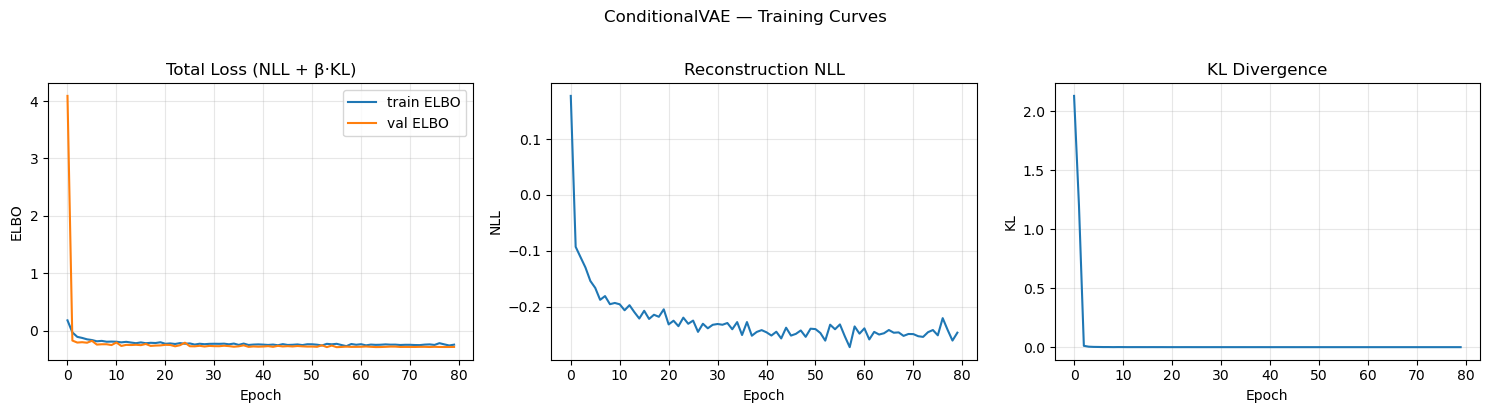

In [12]:
# ── CVAE Loss curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist_cvae['train_loss'], label='train ELBO')
axes[0].plot(hist_cvae['val_loss'],   label='val ELBO')
axes[0].set_ylabel('ELBO'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Total Loss (NLL + β·KL)')

axes[1].plot(hist_cvae['train_nll'])
axes[1].set_ylabel('NLL'); axes[1].set_xlabel('Epoch')
axes[1].set_title('Reconstruction NLL')
axes[1].grid(True, alpha=0.3)

axes[2].plot(hist_cvae['train_kl'])
axes[2].set_ylabel('KL'); axes[2].set_xlabel('Epoch')
axes[2].set_title('KL Divergence')
axes[2].grid(True, alpha=0.3)

fig.suptitle('ConditionalVAE — Training Curves', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Evaluate the CVAE on the test set

In [13]:
rmse_cvae, pred_cvae, true_cvae = evaluate_model(
    model_cvae, dl_test, y_mean_t, y_std_t, CHANNELS, is_cvae=True)

print('ConditionalVAE test RMSE (log10 space):')
for ch, val in rmse_cvae.items():
    print(f'  {ch:20s}  {val:.4f} dex')

ConditionalVAE test RMSE (log10 space):
  gas_density           0.2771 dex
  temperature           1.0001 dex
  pressure              0.4043 dex


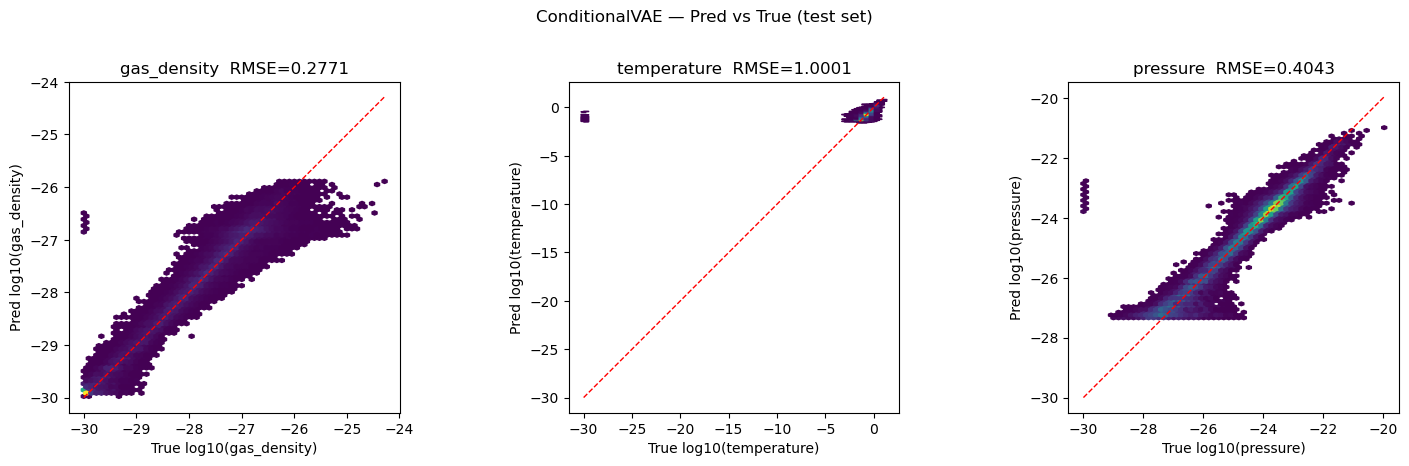

In [14]:
# ── Pred vs True scatter for CVAE ────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(5 * len(CHANNELS), 4.5))
for i, (ch, ax) in enumerate(zip(CHANNELS, axes)):
    ax.hexbin(true_cvae[:, i], pred_cvae[:, i],
              gridsize=60, cmap='viridis', mincnt=1)
    lims = [min(true_cvae[:, i].min(), pred_cvae[:, i].min()),
            max(true_cvae[:, i].max(), pred_cvae[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'True log10({ch})')
    ax.set_ylabel(f'Pred log10({ch})')
    ax.set_title(f'{ch}  RMSE={rmse_cvae[ch]:.4f}')
    ax.set_aspect('equal')
fig.suptitle('ConditionalVAE — Pred vs True (test set)', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Comparison & Analysis

In [15]:
# ── Side-by-side RMSE comparison ─────────────────────────────────────────────
import pandas as pd

comp_df = pd.DataFrame({
    'Channel': CHANNELS,
    'ResNet RMSE (dex)': [rmse_resnet[ch] for ch in CHANNELS],
    'CVAE RMSE (dex)':   [rmse_cvae[ch]   for ch in CHANNELS],
})
comp_df['Δ (CVAE − ResNet)'] = comp_df['CVAE RMSE (dex)'] - comp_df['ResNet RMSE (dex)']
display(comp_df.style.format({
    'ResNet RMSE (dex)': '{:.4f}',
    'CVAE RMSE (dex)': '{:.4f}',
    'Δ (CVAE − ResNet)': '{:+.4f}',
}))

,Channel,ResNet RMSE (dex),CVAE RMSE (dex),Δ (CVAE − ResNet)
0,gas_density,0.2561,0.2771,+0.0210
1,temperature,0.9917,1.0001,+0.0084
2,pressure,0.3987,0.4043,+0.0056


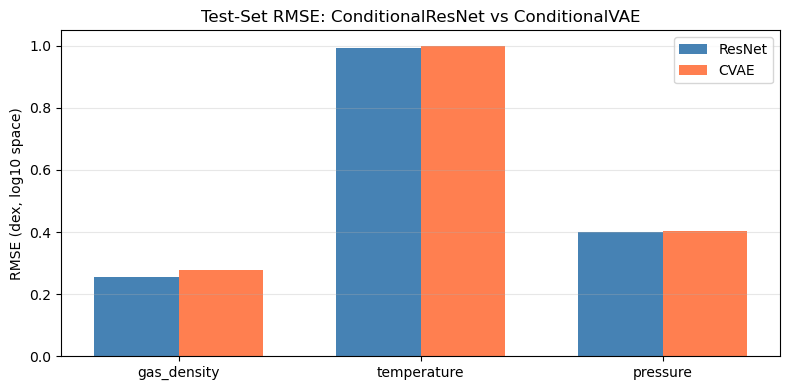

In [16]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(CHANNELS))
w = 0.35
ax.bar(x_pos - w/2, [rmse_resnet[ch] for ch in CHANNELS], w, label='ResNet', color='steelblue')
ax.bar(x_pos + w/2, [rmse_cvae[ch]   for ch in CHANNELS], w, label='CVAE',   color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(CHANNELS)
ax.set_ylabel('RMSE (dex, log10 space)')
ax.set_title('Test-Set RMSE: ConditionalResNet vs ConditionalVAE')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Latent-space exploration (CVAE only)

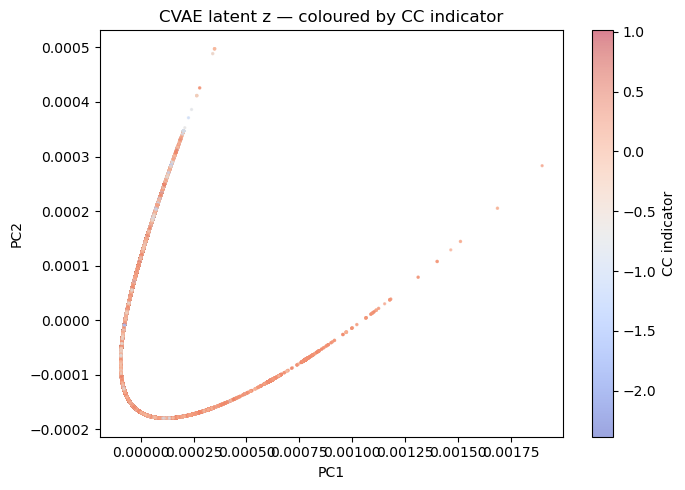

In [17]:
# ── Visualize latent z coloured by CC indicator ──────────────────────────────
model_cvae.eval()

# Collect latent means from the test set
z_means, cc_vals = [], []
with torch.no_grad():
    for xb, yb, ccb in dl_test:
        xb = xb.to(DEVICE)
        q_z = model_cvae._encode(xb)  # noqa: access for viz
        z_means.append(q_z.loc.cpu())
        cc_vals.append(ccb)

z_means = torch.cat(z_means, dim=0).numpy()
cc_vals = torch.cat(cc_vals, dim=0).numpy()

# PCA down to 2D for visualization
from sklearn.decomposition import PCA
z_2d = PCA(n_components=2).fit_transform(z_means)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=cc_vals, s=2, alpha=0.5, cmap='coolwarm')
plt.colorbar(sc, ax=ax, label='CC indicator')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('CVAE latent z — coloured by CC indicator')
plt.tight_layout()
plt.show()

### 3.2 Profile reconstructions — sample halos

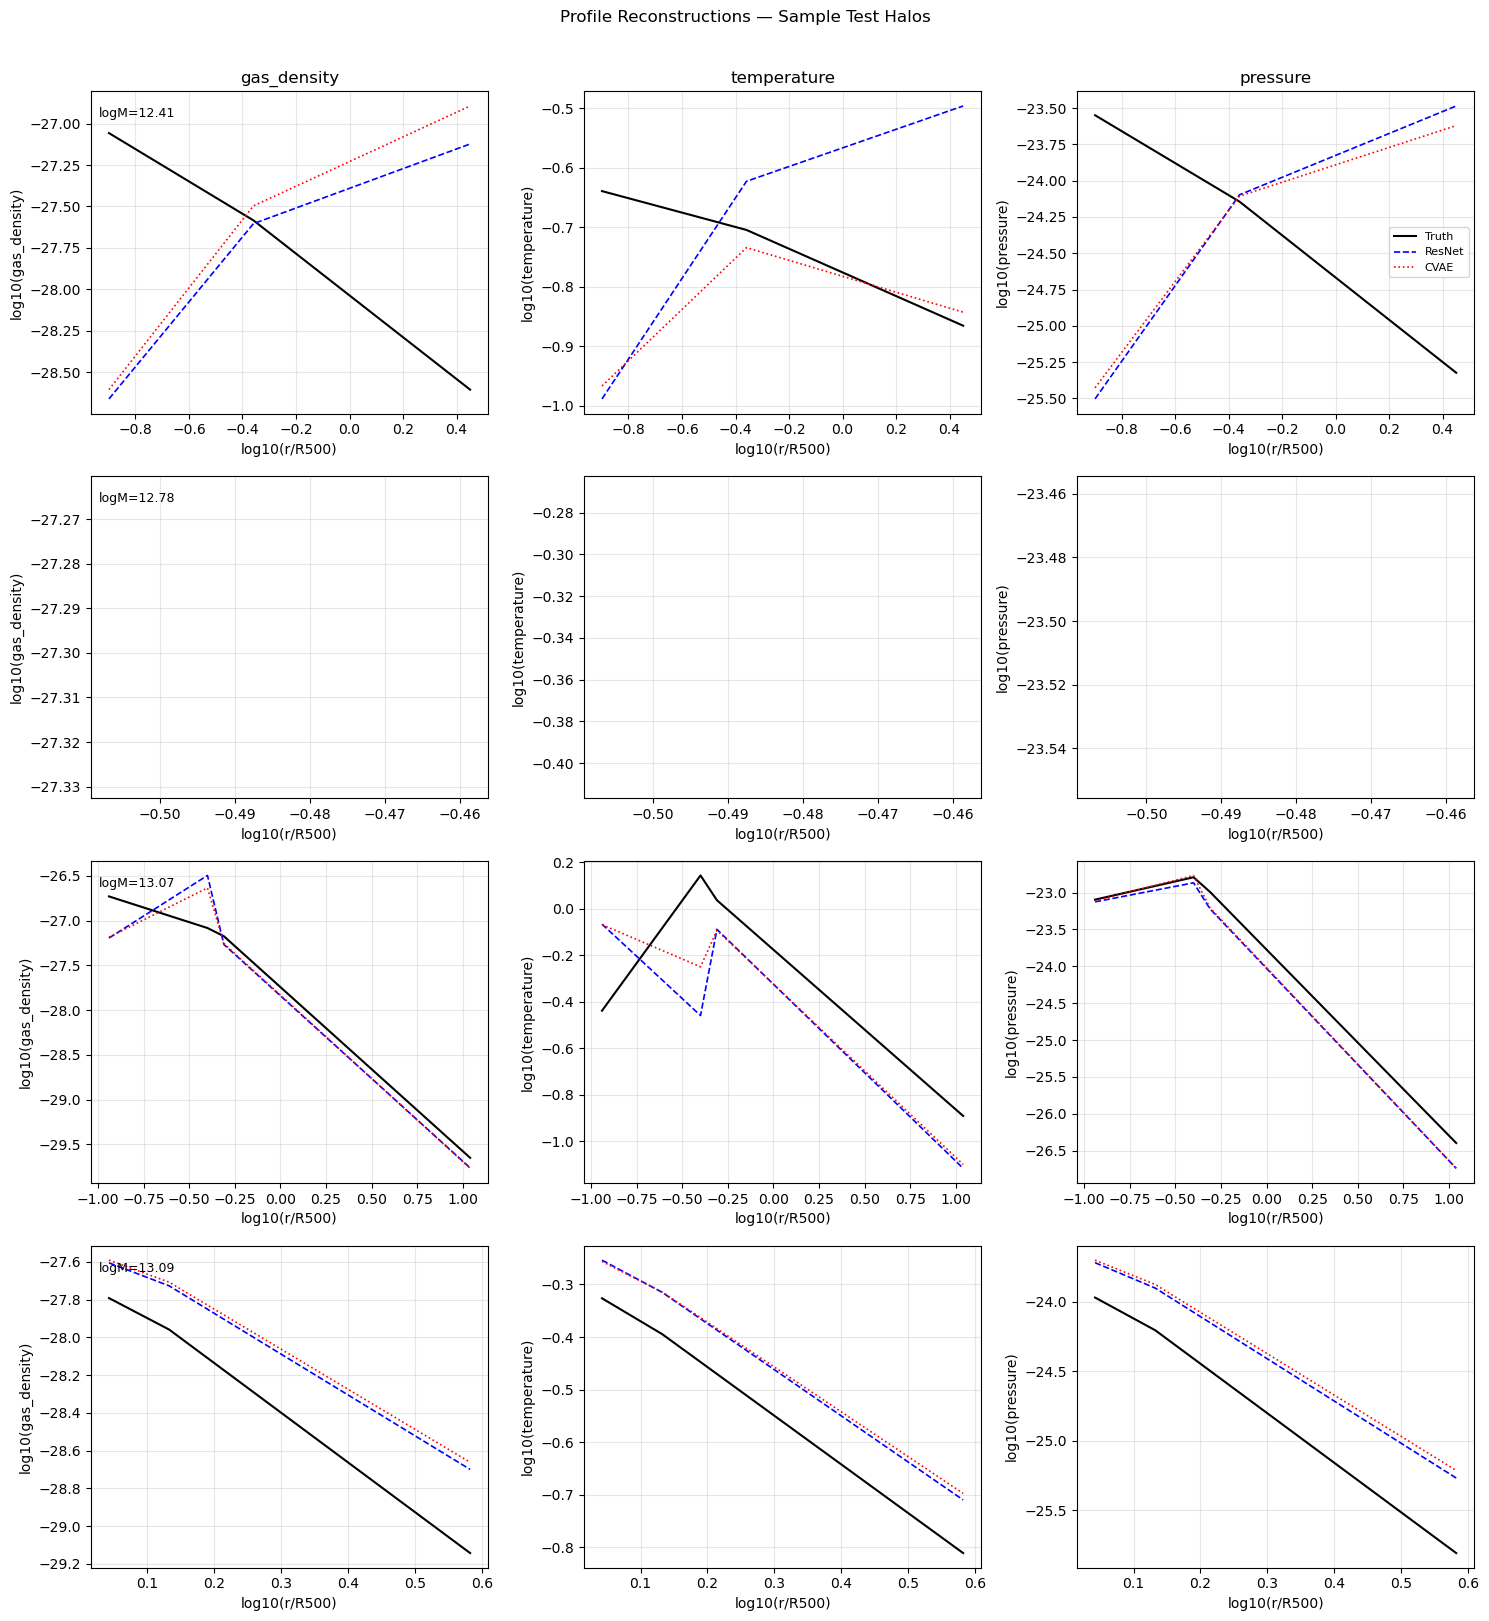

In [18]:
# ── Show a few reconstructed profiles vs truth ───────────────────────────────
# Pick a few halos from the test set (unique logM values)
test_x = X_np[idx_test]
test_y = Y_np[idx_test]
test_cc = CC_np[idx_test]

# Group test points by halo (same logM value within a file)
unique_logM = np.unique(test_x[:, 0])
rng_plot = np.random.RandomState(123)
sample_logM = rng_plot.choice(unique_logM, size=min(4, len(unique_logM)), replace=False)

fig, axes = plt.subplots(len(sample_logM), len(CHANNELS),
                         figsize=(5 * len(CHANNELS), 4 * len(sample_logM)),
                         squeeze=False)

for row, lm in enumerate(sorted(sample_logM)):
    mask_h = test_x[:, 0] == lm
    if mask_h.sum() == 0:
        continue
    xh = test_x[mask_h]
    yh = test_y[mask_h]
    logr = xh[:, 1]  # not normalized
    order = np.argsort(logr)
    logr = logr[order]
    yh = yh[order]

    # Predictions (ResNet)
    xh_norm = normalize(xh, x_mean, x_std).astype(np.float32)
    xh_t = torch.from_numpy(xh_norm).to(DEVICE)
    cc_t = torch.from_numpy(test_cc[mask_h][order]).to(DEVICE)
    is_cc_t = (cc_t < 0).float().unsqueeze(-1)
    with torch.no_grad():
        mu_rn, _ = model_resnet.predict(xh_t, p_cc=is_cc_t)
        mu_cv, _ = model_cvae.predict(xh_t, n_samples=30)
    mu_rn = denormalize(mu_rn.cpu().numpy(), y_mean, y_std)
    mu_cv = denormalize(mu_cv.cpu().numpy(), y_mean, y_std)

    for col, ch in enumerate(CHANNELS):
        ax = axes[row, col]
        ax.plot(logr, yh[:, col], 'k-', lw=1.5, label='Truth')
        ax.plot(logr, mu_rn[:, col], 'b--', lw=1.2, label='ResNet')
        ax.plot(logr, mu_cv[:, col], 'r:', lw=1.2, label='CVAE')
        ax.set_xlabel('log10(r/R500)')
        ax.set_ylabel(f'log10({ch})')
        if row == 0:
            ax.set_title(ch)
        if col == 0:
            ax.annotate(f'logM={lm:.2f}', xy=(0.02, 0.95),
                        xycoords='axes fraction', va='top', fontsize=9)
        if row == 0 and col == len(CHANNELS) - 1:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Profile Reconstructions — Sample Test Halos', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Stochastic diversity (CVAE): multiple z-samples for one halo

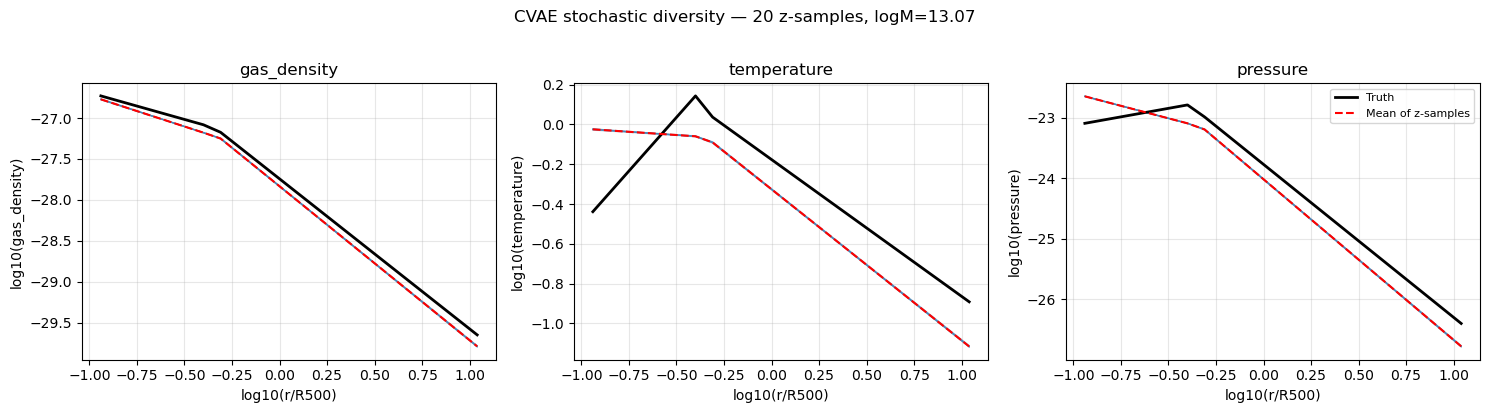

In [19]:
# ── Draw multiple z samples and overlay profiles to show diversity ────────────
# Pick one halo from the test set
idx_halo = np.where(test_x[:, 0] == sample_logM[0])[0]
xh = test_x[idx_halo]
yh = test_y[idx_halo]
logr = xh[:, 1]
order = np.argsort(logr)
logr = logr[order]
yh = yh[order]

xh_norm = normalize(xh, x_mean, x_std).astype(np.float32)
xh_t = torch.from_numpy(xh_norm[order]).to(DEVICE)

N_DRAWS = 20
model_cvae.eval()
draws = []
with torch.no_grad():
    q_z = model_cvae._encode(xh_t)
    for _ in range(N_DRAWS):
        z = q_z.rsample()
        ncc_out, cc_out = model_cvae._decode(xh_t, z)
        mu = ncc_out[0].cpu().numpy()  # use NCC head for viz
        mu = denormalize(mu, y_mean, y_std)
        draws.append(mu)

draws = np.stack(draws, axis=0)  # (N_DRAWS, n_r, y_dim)

fig, axes = plt.subplots(1, len(CHANNELS), figsize=(5 * len(CHANNELS), 4))
for i, (ch, ax) in enumerate(zip(CHANNELS, axes)):
    for d in range(N_DRAWS):
        ax.plot(logr, draws[d, :, i], color='steelblue', alpha=0.2, lw=0.8)
    ax.plot(logr, yh[:, i], 'k-', lw=2, label='Truth')
    ax.plot(logr, draws.mean(axis=0)[:, i], 'r--', lw=1.5, label='Mean of z-samples')
    ax.set_xlabel('log10(r/R500)')
    ax.set_ylabel(f'log10({ch})')
    ax.set_title(ch)
    if i == len(CHANNELS) - 1:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'CVAE stochastic diversity — {N_DRAWS} z-samples, logM={sample_logM[0]:.2f}', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Discussion & Next Steps

### Key differences from StrongANP

| Feature | StrongANP | ConditionalResNet | ConditionalVAE |
|---|---|---|---|
| Context set | Yes (NP) | No | No |
| Latent z | Per-context-set | None | Per-halo `q(z\|M,θ)` |
| θ conditioning | FiLM on decoder | FiLM on ResBlocks | FiLM on ResBlocks |
| CC/NCC heads | Dual | Dual | Dual |
| Few-shot generalization | Built-in | None | Marginal (via learned prior) |
| Architecture complexity | High (Transformer + cross-attn) | Low (ResNet + FiLM) | Low–Medium (encoder + ResNet) |
| Training data format | Context + target sets per halo | Flat `(M,r,θ) → y` | Flat `(M,r,θ) → y` |

### When to prefer which

- **ConditionalResNet**: simplest; best for interpolation where the full θ-grid is
  well-sampled.  No stochastic capacity beyond the CC/NCC split.
- **ConditionalVAE**: retains halo-level stochasticity via z, useful when
  scatter within a (M, θ) bin is physically important (e.g., assembly bias).
  Simpler than StrongANP but less principled than the NP context-set framework.
- **StrongANP**: best for few-shot/meta-learning settings; robust when the
  decoder must generalize to novel θ values with few profile examples.

### Possible extensions

1. **Cross-attention CVAE**: Replace FiLM with cross-attention between the latent
   z (expanded to each radial point) and the θ embedding.  This can capture
   richer θ–z interactions.
2. **1-D UNet**: Replace the ResNet trunk with a 1-D UNet that operates on the
   full radial profile as a sequence.  Requires batching profiles on the fixed
   grid, but gains skip connections and multi-scale features.
3. **Normalizing flow decoder**: Replace the Gaussian output heads with a
   conditional normalizing flow for richer predictive distributions.
4. **Task-uncertainty weighting**: Add learnable per-channel log-σ
   homoscedastic weights (Kendall et al. 2018) as in StrongANP.
5. **Channel balancing**: Apply inverse-RMSE weighting to the NLL to prevent
   large-amplitude channels from dominating.

In [20]:
# ── Parameter count summary ──────────────────────────────────────────────────
print(f'ConditionalResNet: {sum(p.numel() for p in model_resnet.parameters()):>10,} params')
print(f'ConditionalVAE:    {sum(p.numel() for p in model_cvae.parameters()):>10,} params')

ConditionalResNet:  2,561,292 params
ConditionalVAE:     2,607,276 params
